In [1]:
# HÜCRE 1: Kütüphaneler
import pandas as pd
import numpy as np
import os

# Klasörlerin var olduğundan emin olalım (Colab geçici ortam olduğu için)
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

print("Kütüphaneler yüklendi ve klasörler hazır.")

Kütüphaneler yüklendi ve klasörler hazır.


In [2]:
file_path = 'data/raw/koeri_raw.txt'

# sep='\t' parametresi ile Pandas'a "bu dosyadaki sütunlar TAB ile ayrılmıştır" diyoruz.
try:
    df = pd.read_csv(file_path, sep='\t', encoding='windows-1254')
except Exception:
    df = pd.read_csv(file_path, sep='\t', encoding='iso-8859-9')

# Sütun isimlerinin başında/sonunda yanlışlıkla kalmış boşluklar varsa temizleyelim
df.columns = df.columns.str.strip()

# Proje için sadece ihtiyacımız olan sütunları seçelim ve isimlerini düzeltelim
df = df[['Olus tarihi', 'Olus zamani', 'Enlem', 'Boylam', 'Der(km)', 'MD', 'ML', 'Mw', 'Yer']]

df.columns = ['Olus_tarihi', 'Olus_zamani', 'Enlem', 'Boylam', 'Der_km', 'MD', 'ML', 'Mw', 'Yer']

print("✅ Sekme (TAB) ayracı ile veri mükemmel şekilde okundu!")
display(df.head())
display(df.tail())

✅ Sekme (TAB) ayracı ile veri mükemmel şekilde okundu!


,Olus_tarihi,Olus_zamani,Enlem,Boylam,Der_km,MD,ML,Mw,Yer
0,2024.12.31,10:46:27.00,38.0710,37.5068,6.7,0.0,4.0,3.9,TATLAR-NURHAK (KAHRAMANMARAS) [North West 8.1...
1,2024.12.30,20:30:27.56,39.4170,37.2977,5.0,0.0,4.3,4.3,KERTMEKARACAOREN-ULAS (SIVAS) [South West 2.1...
2,2024.12.30,02:25:17.55,36.7442,30.1467,7.1,0.0,3.9,3.8,OVACIK-ELMALI (ANTALYA) [South West 6.4 km]
3,2024.12.29,00:15:10.00,35.1408,27.2722,10.6,0.0,4.1,4.3,AKDENIZ
4,2024.12.28,11:44:00.95,41.2442,44.0308,5.0,0.0,3.6,3.7,GURCISTAN


,Olus_tarihi,Olus_zamani,Enlem,Boylam,Der_km,MD,ML,Mw,Yer
12732,2000.01.03,13:54:53.10,40.90,42.06,32.0,3.6,0.0,NaN,ATLI-OLUR (ERZURUM) [East 1.8 km]
12733,2000.01.02,20:28:37.00,38.43,38.76,19.0,4.1,0.0,NaN,KALE (MALATYA) [North West 1.3 km]
12734,2000.01.02,02:16:20.00,38.83,25.51,12.0,3.5,0.0,NaN,EGE DENIZI
12735,2000.01.02,00:29:24.10,40.86,30.87,9.0,3.5,0.0,NaN,BICKIATIK-HENDEK (SAKARYA) [North East 0.9 km]
12736,2000.01.01,07:16:42.30,40.95,27.91,9.0,3.5,0.0,NaN,MARMARAEREGLISI (TEKIRDAG) [South West 4.3 km]


In [4]:
# 1. Tarih ve Saati birleştirip gerçek 'datetime' tipine çevirme
df['datetime'] = pd.to_datetime(df['Olus_tarihi'] + ' ' + df['Olus_zamani'], errors='coerce')

# 2. Sayısal olması gereken sütunları float'a (ondalıklı sayı) çevirme
numeric_cols = ['Enlem', 'Boylam', 'Der_km', 'MD', 'ML', 'Mw']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Büyüklük Önceliği Kuralı (Mw > ML > MD)
conditions = [
    df['Mw'].notna() & (df['Mw'] > 0),
    df['ML'].notna() & (df['ML'] > 0),
    df['MD'].notna() & (df['MD'] > 0)
]
choices = [df['Mw'], df['ML'], df['MD']]
df['magnitude'] = np.select(conditions, choices, default=np.nan)

# 4. Proje standartlarına (İngilizce isimlere) çevir
df = df.rename(columns={
    'Enlem': 'lat',
    'Boylam': 'lon',
    'Der_km': 'depth_km'
})

print("✅ Tip dönüşümleri ve magnitüd hiyerarşisi tamamlandı.")
display(df[['datetime', 'lat', 'lon', 'depth_km', 'magnitude']].head())

✅ Tip dönüşümleri ve magnitüd hiyerarşisi tamamlandı.


,datetime,lat,lon,depth_km,magnitude
0,2024-12-31 10:46:27.000,38.0710,37.5068,6.7,3.9
1,2024-12-30 20:30:27.560,39.4170,37.2977,5.0,4.3
2,2024-12-30 02:25:17.550,36.7442,30.1467,7.1,3.8
3,2024-12-29 00:15:10.000,35.1408,27.2722,10.6,4.3
4,2024-12-28 11:44:00.950,41.2442,44.0308,5.0,3.7


In [5]:
# Orijinal boyutu not alalım
baslangic_boyutu = len(df)

# Sadece makine öğrenmesi modelinde kullanacağımız sütunları seçelim
df_clean = df[['datetime', 'lat', 'lon', 'depth_km', 'magnitude']].copy()

# Eksik (NaN) veya hatalı değerleri sil
df_clean = df_clean.dropna()

# Mantıksız verileri temizle (Örn: negatif derinlik veya aşırı büyük magnitüd)
df_clean = df_clean[
    (df_clean['magnitude'] > 0) & (df_clean['magnitude'] <= 9.0) &
    (df_clean['depth_km'] >= 0) & (df_clean['depth_km'] <= 700)
]

# Proje Kutu Filtresi (Belirttiğiniz Koordinatlar: 35.0-43.0°N, 25.0-46.0°E)
df_clean = df_clean[
    (df_clean['lat'] >= 35.0) & (df_clean['lat'] <= 43.0) &
    (df_clean['lon'] >= 25.0) & (df_clean['lon'] <= 46.0)
]

# Aynı saniye ve koordinattaki mükerrer (duplicate) kayıtları sil
df_clean = df_clean.drop_duplicates(subset=['datetime', 'lat', 'lon'])

# Zaman serisi (Time Series) projeleri için ÇOK KRİTİK: Kronolojik sırala
df_clean = df_clean.sort_values('datetime').reset_index(drop=True)

bitis_boyutu = len(df_clean)

print("--- VERİ TEMİZLİĞİ ÖZETİ ---")
print(f"Başlangıçtaki Satır Sayısı: {baslangic_boyutu}")
print(f"Kutu Dışı ve Hatalı Silinen: {baslangic_boyutu - bitis_boyutu}")
print(f"Eğitime Hazır Temiz Veri: {bitis_boyutu}")

# --- HÜCRE 4'ÜN SADECE EN ALT KISMINI BÖYLE DEĞİŞTİRİN ---

# CSV formatında kaydet (Parquet hatasını aşmak için)
output_path = 'data/processed/koeri_clean.csv'

# index=False ile satır numaralarını kaydetmiyoruz
df_clean.to_csv(output_path, index=False)

print(f"\n🚀 Aşama 1 Başarılı! Temiz veri '{output_path}' konumuna kaydedildi.")

--- VERİ TEMİZLİĞİ ÖZETİ ---
Başlangıçtaki Satır Sayısı: 12737
Kutu Dışı ve Hatalı Silinen: 16
Eğitime Hazır Temiz Veri: 12721

🚀 Aşama 1 Başarılı! Temiz veri 'data/processed/koeri_clean.csv' konumuna kaydedildi.


In [7]:
# Alp Demir & Taha Atasoy - Özellik Mühendisliği (Bölüm 1)
import pandas as pd
import numpy as np

# Temizlenmiş CSV dosyamızı yüklüyoruz (Parquet yerine)
df = pd.read_csv('data/processed/koeri_clean.csv')

# CSV'den okuduğumuz datetime sütununu tekrar tarih formatına çevirmemiz lazım
df['datetime'] = pd.to_datetime(df['datetime'])

# Zamana göre sıralı olduğundan %100 emin olalım
df = df.sort_values('datetime').reset_index(drop=True)

# ---------------------------------------------------------
# 1. HEDEF DEĞİŞKEN (TARGET) - Taha'nın Görevi
# ---------------------------------------------------------
df['target'] = (df['magnitude'] >= 4.2).astype(int)

oran = df['target'].mean() * 100
print(f"Hedef Değişken (Target) Oluşturuldu.")
print(f"Toplam Deprem: {len(df)}")
print(f"4.2 Üzeri Deprem Sayısı (Pozitif Sınıf): {df['target'].sum()}")
print(f"Pozitif Sınıf Oranı: %{oran:.2f}\n")

# ---------------------------------------------------------
# 2. LAG ÖZELLİKLERİ (Geçmiş Zaman) - Alp'in Görevi
# ---------------------------------------------------------
df['time_since_last_event_hours'] = df['datetime'].diff().dt.total_seconds() / 3600.0
df['prev_magnitude'] = df['magnitude'].shift(1)

print("✅ Geçmiş (Lag) özellikleri eklendi.")
display(df[['datetime', 'magnitude', 'target', 'time_since_last_event_hours', 'prev_magnitude']].head())
display(df[['datetime', 'magnitude', 'target', 'time_since_last_event_hours', 'prev_magnitude']].tail())

Hedef Değişken (Target) Oluşturuldu.
Toplam Deprem: 12721
4.2 Üzeri Deprem Sayısı (Pozitif Sınıf): 2074
Pozitif Sınıf Oranı: %16.30

✅ Geçmiş (Lag) özellikleri eklendi.


,datetime,magnitude,target,time_since_last_event_hours,prev_magnitude
0,2000-01-01 07:16:42.300,3.5,0,NaN,NaN
1,2000-01-02 00:29:24.100,3.5,0,17.211611,3.5
2,2000-01-02 02:16:20.000,3.5,0,1.782194,3.5
3,2000-01-02 20:28:37.000,4.1,0,18.204722,3.5
4,2000-01-03 13:54:53.100,3.6,0,17.437806,4.1


,datetime,magnitude,target,time_since_last_event_hours,prev_magnitude
12716,2024-12-28 11:44:00.950,3.7,0,40.923881,3.5
12717,2024-12-29 00:15:10.000,4.3,1,12.519181,3.7
12718,2024-12-30 02:25:17.550,3.8,0,26.168764,4.3
12719,2024-12-30 20:30:27.560,4.3,1,18.086114,3.8
12720,2024-12-31 10:46:27.000,3.9,0,14.266511,4.3


In [8]:
# ---------------------------------------------------------
# 3. ROLLING ÖZELLİKLERİ (Kayan Pencereler) - Alp'in Görevi
# ---------------------------------------------------------
import pandas as pd
import numpy as np

# Pandas rolling index üzerinden çalıştığı için datetime'ı index yapıyoruz
df_roll = df.set_index('datetime').copy()

# Pencerelerimiz: 7 gün ve 30 gün
windows = ['7D', '30D']

for w in windows:
    # 1. Belirli bir penceredeki toplam deprem sayısı
    # closed='left' çok kritik! "Şu an olan depremi sayma, sadece ÖNCEKİLERİ say" demek.
    count_col = f'count_events_{w}'
    df_roll[count_col] = df_roll['magnitude'].rolling(window=w, closed='left').count()

    # 2. Belirli bir penceredeki maksimum magnitüd
    max_col = f'max_mag_{w}'
    df_roll[max_col] = df_roll['magnitude'].rolling(window=w, closed='left').max()

    # 3. Belirli bir penceredeki ortalama büyüklük
    mean_col = f'mean_mag_{w}'
    df_roll[mean_col] = df_roll['magnitude'].rolling(window=w, closed='left').mean()

# Index'i geri sütuna alıyoruz
df = df_roll.reset_index()

# Rolling hesaplamaları başlardaki satırlar için (geçmişi olmadığı için) boş (NaN) değerler üretecektir.
# Bu projede makine öğrenmesi algoritmaları (özellikle baseline olan Logistic Regression) NaN sevmez.
print(f"Rolling öncesi satır sayısı: {len(df)}")
df_features = df.dropna().reset_index(drop=True)
print(f"Eksik (NaN) özellikler silindikten sonra satır sayısı: {len(df_features)}")

print("\n✅ Kayan Pencere (Rolling) özellikleri eklendi ve Leakage (Sızıntı) engellendi!")
display(df_features[['datetime', 'magnitude', 'count_events_7D', 'max_mag_30D']].tail())

Rolling öncesi satır sayısı: 12721
Eksik (NaN) özellikler silindikten sonra satır sayısı: 12684

✅ Kayan Pencere (Rolling) özellikleri eklendi ve Leakage (Sızıntı) engellendi!


,datetime,magnitude,count_events_7D,max_mag_30D
12679,2024-12-28 11:44:00.950,3.7,6.0,4.7
12680,2024-12-29 00:15:10.000,4.3,7.0,4.7
12681,2024-12-30 02:25:17.550,3.8,7.0,4.7
12682,2024-12-30 20:30:27.560,4.3,8.0,4.7
12683,2024-12-31 10:46:27.000,3.9,9.0,4.7


In [9]:
import pandas as pd

# 1. Final Özellik Matrisini Kaydetme
output_features = 'data/processed/features.csv'
df_features.to_csv(output_features, index=False)
print(f"✅ Final özellik matrisi kaydedildi: {output_features}")

# 2. MODEL İÇİN GEREKSİZ SÜTUNLARI ÇIKARMA
# datetime sadece bölme işlemi için kullanılacak, modele girmeyecek.
# magnitude zaten target'ın kendisi (4.2 üstü mü değil mi?), o yüzden modele veremeyiz (büyük bir leakage olur!)
drop_cols = ['datetime', 'magnitude', 'target']
X = df_features.drop(columns=drop_cols)
y = df_features['target']
tarihler = df_features['datetime']

# 3. KRONOLOJİK BÖLÜNME (Proje Planı Tarihleri)
# Train: 2000 - 2019 sonu
# Val: 2020 - 2022 sonu
# Test: 2023 - 2024 sonu

train_mask = (tarihler >= '2000-01-01') & (tarihler <= '2019-12-31')
val_mask = (tarihler >= '2020-01-01') & (tarihler <= '2022-12-31')
test_mask = (tarihler >= '2023-01-01') & (tarihler <= '2024-12-31')

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("\n--- Veri Seti Bölünme Özeti ---")
print(f"Eğitim (Train) Seti: {len(X_train)} satır")
print(f"Doğrulama (Val) Seti: {len(X_val)} satır")
print(f"Test Seti: {len(X_test)} satır (Sona kadar dokunulmayacak!)")

✅ Final özellik matrisi kaydedildi: data/processed/features.csv

--- Veri Seti Bölünme Özeti ---
Eğitim (Train) Seti: 8403 satır
Doğrulama (Val) Seti: 1920 satır
Test Seti: 2360 satır (Sona kadar dokunulmayacak!)


⏳ Logistic Regression Baseline modeli eğitiliyor...
✅ Eğitim tamamlandı!

--- BASELINE (LOGISTIC REGRESSION) VALIDATION SONUÇLARI ---
PR-AUC (Birincil Metrik) : 0.2268
ROC-AUC                : 0.5511
Recall (Duyarlılık)    : 0.7263
F1 Skoru               : 0.3120


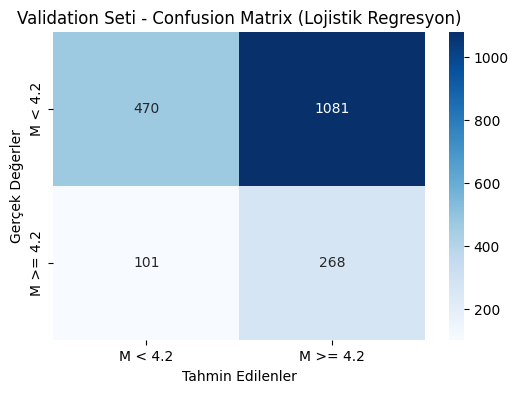

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. PIPELINE KURULUMU (Esma'nın görevi)
# Standartlaştırma (Scaler) ve Modeli birleştiriyoruz.
# class_weight='balanced' dengesiz %16'lık sınıfımızı eşitler.
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# Modeli SADECE Eğitim (Train) setiyle eğitiyoruz!
print("⏳ Logistic Regression Baseline modeli eğitiliyor...")
pipeline_lr.fit(X_train, y_train)
print("✅ Eğitim tamamlandı!")

# 2. DOĞRULAMA (VALIDATION) SETİ ÜZERİNDE TAHMİN
# Modeli, daha önce hiç görmediği 2020-2022 yılları üzerinde test ediyoruz
y_val_pred = pipeline_lr.predict(X_val)
y_val_proba = pipeline_lr.predict_proba(X_val)[:, 1] # PR-AUC ve ROC-AUC için olasılıklar

# 3. METRİKLER (Taha'nın Görevi)
# Proje planındaki birincil metrik PR-AUC'dur.
pr_auc = average_precision_score(y_val, y_val_proba)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

print("\n--- BASELINE (LOGISTIC REGRESSION) VALIDATION SONUÇLARI ---")
print(f"PR-AUC (Birincil Metrik) : {pr_auc:.4f}")
print(f"ROC-AUC                : {roc_auc:.4f}")
print(f"Recall (Duyarlılık)    : {recall:.4f}")
print(f"F1 Skoru               : {f1:.4f}")

# 4. KARIŞIKLIK MATRİSİ (Confusion Matrix) Görseli - Efe'nin template'i için
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['M < 4.2', 'M >= 4.2'], yticklabels=['M < 4.2', 'M >= 4.2'])
plt.title('Validation Seti - Confusion Matrix (Lojistik Regresyon)')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilenler')
plt.show()

XGBoost için scale_pos_weight değeri: 6.13
⏳ XGBoost modeli eğitiliyor (Bu biraz sürebilir)...
✅ Eğitim tamamlandı!

--- XGBOOST VALIDATION SONUÇLARI ---
PR-AUC (Birincil Metrik) : 0.1954 (Baseline: 0.2268)
ROC-AUC                : 0.5067
Recall (Duyarlılık)    : 0.1165
F1 Skoru               : 0.1445


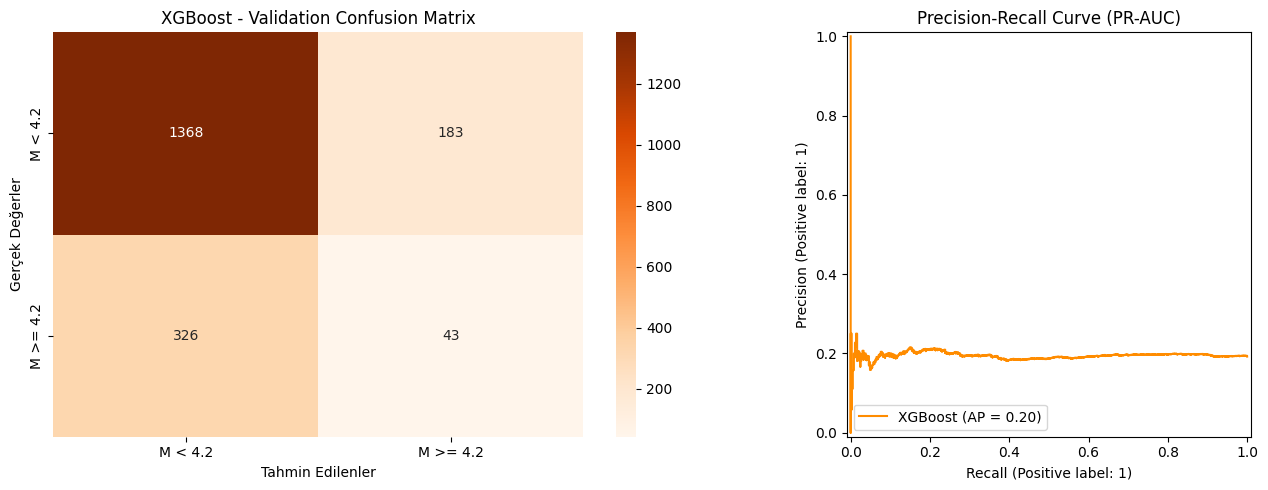

In [ ]:
# HÜCRE 9: XGBoost Modeli (Esma'nın Ana Modeli)
import xgboost as xgb
from sklearn.metrics import average_precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sınıf Dengesizliği İçin Ölçekleme (scale_pos_weight)
# Negatif Sınıf (0) Sayısı / Pozitif Sınıf (1) Sayısı
# Bu, XGBoost'un 'balanced' parametresidir.
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_weight = neg_class_count / pos_class_count

print(f"XGBoost için scale_pos_weight değeri: {scale_weight:.2f}")

# 2. XGBoost Modelini Tanımlama
# Proje planındaki hiperparametreleri (n_estimators=500, max_depth=6 vb.) kullanıyoruz
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1 # Tüm işlemci çekirdeklerini kullan
)

# Not: Ağaç bazlı modellerde (XGBoost, Random Forest) StandardScaler kullanmaya gerek yoktur.
# Doğrudan eğitime geçiyoruz.
print("⏳ XGBoost modeli eğitiliyor (Bu biraz sürebilir)...")
xgb_model.fit(X_train, y_train)
print("✅ Eğitim tamamlandı!")

# 3. DOĞRULAMA (VALIDATION) SETİ ÜZERİNDE TAHMİN
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

# 4. METRİKLERİ HESAPLAMA
pr_auc_xgb = average_precision_score(y_val, y_val_proba_xgb)
recall_xgb = recall_score(y_val, y_val_pred_xgb)
f1_xgb = f1_score(y_val, y_val_pred_xgb)
roc_auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)

print("\n--- XGBOOST VALIDATION SONUÇLARI ---")
print(f"PR-AUC (Birincil Metrik) : {pr_auc_xgb:.4f} (Baseline: 0.2268)")
print(f"ROC-AUC                : {roc_auc_xgb:.4f}")
print(f"Recall (Duyarlılık)    : {recall_xgb:.4f}")
print(f"F1 Skoru               : {f1_xgb:.4f}")

# 5. GÖRSELLEŞTİRME (Karmaşıklık Matrisi ve PR Eğrisi)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matris
cm_xgb = confusion_matrix(y_val, y_val_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['M < 4.2', 'M >= 4.2'], yticklabels=['M < 4.2', 'M >= 4.2'], ax=ax[0])
ax[0].set_title('XGBoost - Validation Confusion Matrix')
ax[0].set_ylabel('Gerçek Değerler')
ax[0].set_xlabel('Tahmin Edilenler')

# PR Curve (Hassasiyet-Duyarlılık Eğrisi) - Projenin Ana Görseli
PrecisionRecallDisplay.from_estimator(xgb_model, X_val, y_val, ax=ax[1], color='darkorange', name='XGBoost')
ax[1].set_title('Precision-Recall Curve (PR-AUC)')

plt.tight_layout()
plt.show()

Varsayılan Eşik: 0.5000 -> F1 Skoru: 0.1445
Bulunan EN İYİ Eşik (Threshold): 0.0165 -> Yeni F1 Skoru: 0.3258

--- YENİ EŞİK DEĞERİYLE METRİKLER ---
Yeni Recall (Duyarlılık): 0.9946 (Eski hali: 0.1165)

--- ÖZELLİK ÖNEM SIRALAMASI (FEATURE IMPORTANCE) ---
1. mean_mag_30D: 0.0993
2. max_mag_7D: 0.0952
3. time_since_last_event_hours: 0.0936
4. max_mag_30D: 0.0930
5. lon: 0.0921
6. depth_km: 0.0916
7. mean_mag_7D: 0.0913
8. lat: 0.0898
9. count_events_30D: 0.0878
10. prev_magnitude: 0.0847
11. count_events_7D: 0.0817


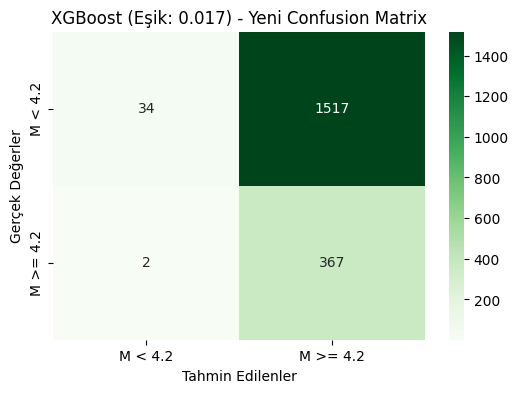

In [ ]:
# HÜCRE 10: Taha & Esma - Threshold Tuning ve Feature Importance
import numpy as np
from sklearn.metrics import precision_recall_curve

# 1. EN İYİ EŞİK DEĞERİNİ (THRESHOLD) BULMA
# Modelin ürettiği olasılıkları alıyoruz
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba_xgb)

# F1 skorunu maksimize eden threshold'u arıyoruz
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-10) # 0'a bölünme hatasını önlemek için 1e-10
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Varsayılan Eşik: 0.5000 -> F1 Skoru: {f1_xgb:.4f}")
print(f"Bulunan EN İYİ Eşik (Threshold): {best_threshold:.4f} -> Yeni F1 Skoru: {best_f1:.4f}\n")

# 2. YENİ EŞİKLE MODELİ TEKRAR TEST ETME
y_val_pred_adjusted = (y_val_proba_xgb >= best_threshold).astype(int)
yeni_recall = recall_score(y_val, y_val_pred_adjusted)

print("--- YENİ EŞİK DEĞERİYLE METRİKLER ---")
print(f"Yeni Recall (Duyarlılık): {yeni_recall:.4f} (Eski hali: {recall_xgb:.4f})")

# 3. XGBOOST HANGİ ÖZELLİKLERE BAKIYOR? (Feature Importance)
# Modelin mantığını anlıyoruz
feature_names = X_train.columns
importances = xgb_model.feature_importances_

# Önem sırasına göre diz
indices = np.argsort(importances)[::-1]

print("\n--- ÖZELLİK ÖNEM SIRALAMASI (FEATURE IMPORTANCE) ---")
for f in range(len(feature_names)):
    print(f"{f+1}. {feature_names[indices[f]]}: {importances[indices[f]]:.4f}")

# Yeni Matrisi Çizelim
cm_adjusted = confusion_matrix(y_val, y_val_pred_adjusted)
plt.figure(figsize=(6,4))
sns.heatmap(cm_adjusted, annot=True, fmt='d', cmap='Greens', xticklabels=['M < 4.2', 'M >= 4.2'], yticklabels=['M < 4.2', 'M >= 4.2'])
plt.title(f'XGBoost (Eşik: {best_threshold:.3f}) - Yeni Confusion Matrix')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilenler')
plt.show()


In [ ]:
# HÜCRE 11: Alp Demir - İleri Seviye Özellik Mühendisliği (b-value & KNN)
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

# En son kaldığımız CSV dosyamızı (Önceki 12.684 satırlık dosya) yükleyelim
df = pd.read_csv('data/processed/features.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# İşlemlerin doğru çalışması için kronolojik sıralama (Yine çok kritik!)
df = df.sort_values('datetime').reset_index(drop=True)

# ---------------------------------------------------------
# 1. b-value (Gutenberg-Richter) HESAPLAMA
# Aki'nin Maximum Likelihood formülü: b = log10(e) / (Ortalama_Mag - Min_Mag)
# Proje Planı: 90 günlük rolling pencere
# ---------------------------------------------------------
print("⏳ b-value hesaplanıyor (Bu işlem 1-2 dakika sürebilir)...")

# Hesaplamayı yapacak fonksiyon (Her satır için geçmiş 90 güne bakacak)
def calculate_b_value(magnitudes, min_mag=df['magnitude'].min()):
    # Sismolojide b-value hesaplanabilmesi için o pencerede en az 30 deprem olmalıdır (istatistiksel güvenilirlik)
    if len(magnitudes) < 30:
        return np.nan

    mean_mag = np.mean(magnitudes)
    # Aki formülü (0.05 düzeltme faktörü ile)
    if mean_mag <= min_mag:
        return np.nan

    b = np.log10(np.e) / (mean_mag - min_mag)
    return b

# Kayan pencere ile uygulama (Yine 'closed=left' kullanarak Leakage'ı önlüyoruz)
df_bval = df.set_index('datetime').copy()
df_bval['b_value_90D'] = df_bval['magnitude'].rolling('90D', closed='left').apply(calculate_b_value, raw=True)
df = df_bval.reset_index()

# ---------------------------------------------------------
# 2. KNN (Mekânsal Komşuluk - Spatial Features)
# Her olay için, geçmişteki olaylar arasından coğrafi olarak en yakın K=5 komşuyu bulma
# ---------------------------------------------------------
print("⏳ KNN (Mekânsal Komşuluk) özellikleri hesaplanıyor...")

# Koordinatları radyana çeviriyoruz (Haversine mesafe formülü için şarttır)
df['lat_rad'] = np.radians(df['lat'])
df['lon_rad'] = np.radians(df['lon'])

k_neighbors = 5
knn_mean_mag = np.zeros(len(df))
knn_mean_depth = np.zeros(len(df))

# İlk K kadar satırda komşu arayamayız, onları NaN bırakacağız
knn_mean_mag[:k_neighbors] = np.nan
knn_mean_depth[:k_neighbors] = np.nan

# BallTree ile Haversine (Gerçek dünya mesafesi) kullanımı daha etkilidir ancak
# zaman serilerinde geçmişten geleceğe sızıntıyı (leakage) önlemek için satır satır ilerlemek GÜVENLİ yoldur.
# Bu döngü, her i. satır için sadece 0'dan i-1'e kadar olan (geçmişteki) depremler içinde en yakın komşuları arar.
for i in range(k_neighbors, len(df)):

    # Sadece geçmişteki olaylar
    past_coords = df[['lat_rad', 'lon_rad']].iloc[:i].values
    current_coord = df[['lat_rad', 'lon_rad']].iloc[i].values.reshape(1, -1)

    # Geçmişteki verilerle KNN ağacı kur
    nn = NearestNeighbors(n_neighbors=min(k_neighbors, i), algorithm='ball_tree', metric='haversine')
    nn.fit(past_coords)

    # Şu anki depremin koordinatına en yakın olanları bul
    distances, indices = nn.kneighbors(current_coord)

    # Komşuların indexleri
    neighbor_indices = indices[0]

    # Komşuların özelliklerini hesapla
    knn_mean_mag[i] = df['magnitude'].iloc[neighbor_indices].mean()
    knn_mean_depth[i] = df['depth_km'].iloc[neighbor_indices].mean()

    # İlerleme durumu (Her 2000 satırda bir)
    if i % 2000 == 0:
        print(f"   İlerlenen satır: {i}/{len(df)}")

df['knn_mean_mag_5'] = knn_mean_mag
df['knn_mean_depth_5'] = knn_mean_depth

# İşimiz biten radyan sütunlarını çöpe atalım
df = df.drop(columns=['lat_rad', 'lon_rad'])

# İlk 90 gün (b-value sebebiyle) ve ilk 5 olay (KNN sebebiyle) boş değer (NaN) üretti. Onları temizliyoruz.
df_advanced_features = df.dropna().reset_index(drop=True)

print(f"\n✅ Zeki özellikler eklendi! Yeni satır sayısı: {len(df_advanced_features)}")
display(df_advanced_features[['datetime', 'b_value_90D', 'knn_mean_mag_5', 'knn_mean_depth_5']].tail())

# Modeli taze taze eğitmek için bu yeni dosyayı kaydedelim
output_advanced = 'data/processed/features_advanced.csv'
df_advanced_features.to_csv(output_advanced, index=False)
print(f"🚀 Yeni matris '{output_advanced}' olarak kaydedildi.")

⏳ b-value hesaplanıyor (Bu işlem 1-2 dakika sürebilir)...
⏳ KNN (Mekânsal Komşuluk) özellikleri hesaplanıyor...
   İlerlenen satır: 2000/12684
   İlerlenen satır: 4000/12684
   İlerlenen satır: 6000/12684
   İlerlenen satır: 8000/12684
   İlerlenen satır: 10000/12684
   İlerlenen satır: 12000/12684

✅ Zeki özellikler eklendi! Yeni satır sayısı: 12654


,datetime,b_value_90D,knn_mean_mag_5,knn_mean_depth_5
12649,2024-12-28 11:44:00.950,0.572193,3.96,8.06
12650,2024-12-29 00:15:10.000,0.573382,3.68,12.66
12651,2024-12-30 02:25:17.550,0.570116,3.80,43.42
12652,2024-12-30 20:30:27.560,0.570851,4.00,4.50
12653,2024-12-31 10:46:27.000,0.568183,3.68,7.72


🚀 Yeni matris 'data/processed/features_advanced.csv' olarak kaydedildi.


⏳ Modeller eğitiliyor (Önce XGBoost, sonra Random Forest)...
✅ Eğitimler tamamlandı!

🏆 --- ŞAMPİYONLAR LİGİ: PR-AUC (Birincil Metrik) ---
Eski XGBoost (Zeki özellikler olmadan) : ~0.1954
Esma'nın YENİ XGBoost'u                : 0.2083
Onur'un YENİ Random Forest'ı           : 0.2200


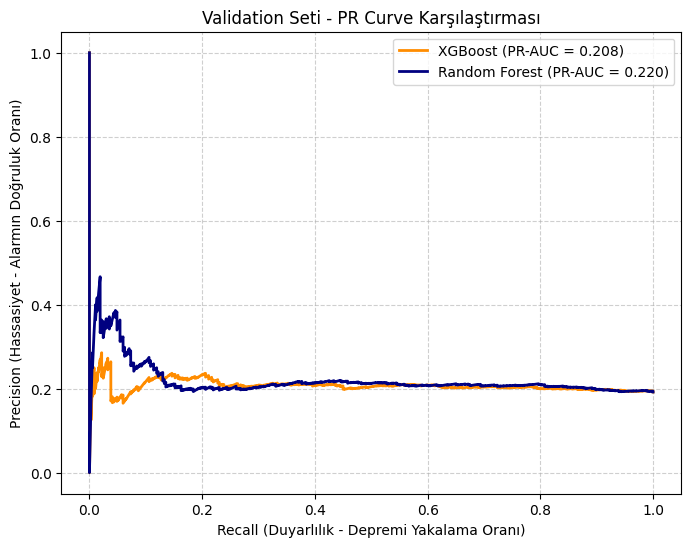


🔍 YENİ ÖZELLİK ÖNEM SIRALAMASI (XGBoost):
1. b_value_90D: 0.0938
2. lon: 0.0740
3. mean_mag_7D: 0.0735
4. depth_km: 0.0733
5. mean_mag_30D: 0.0729


In [ ]:
# HÜCRE 12: Esma (XGBoost) vs Onur (Random Forest) - Büyük Karşılaşma
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# 1. YENİ VERİ SETİNİ YÜKLEME VE BÖLME
df = pd.read_csv('data/processed/features_advanced.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

X = df.drop(columns=['datetime', 'magnitude', 'target'])
y = df['target']
tarihler = df['datetime']

# Kronolojik Bölünme (Train: 2000-2019, Val: 2020-2022)
train_mask = (tarihler >= '2000-01-01') & (tarihler <= '2019-12-31')
val_mask = (tarihler >= '2020-01-01') & (tarihler <= '2022-12-31')

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

# XGBoost için sınıf ağırlığı
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("⏳ Modeller eğitiliyor (Önce XGBoost, sonra Random Forest)...")

# 2. ESMA'NIN MODELİ: XGBOOST
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_weight, random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

# 3. ONUR'UN MODELİ: RANDOM FOREST (Proje Planı Parametreleriyle)
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

print("✅ Eğitimler tamamlandı!\n")

# 4. BİRİNCİL METRİK (PR-AUC) KARŞILAŞTIRMASI
# PR-AUC eşik (threshold) değerinden bağımsızdır, modelin saf gücünü ölçer.
pr_auc_xgb = average_precision_score(y_val, y_val_proba_xgb)
pr_auc_rf = average_precision_score(y_val, y_val_proba_rf)

print("🏆 --- ŞAMPİYONLAR LİGİ: PR-AUC (Birincil Metrik) ---")
print(f"Eski XGBoost (Zeki özellikler olmadan) : ~0.1954")
print(f"Esma'nın YENİ XGBoost'u                : {pr_auc_xgb:.4f}")
print(f"Onur'un YENİ Random Forest'ı           : {pr_auc_rf:.4f}")

# 5. GÖRSELLEŞTİRME (PR Eğrileri Karşılaştırması)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_val, y_val_proba_xgb)
precision_rf, recall_rf, _ = precision_recall_curve(y_val, y_val_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, color='darkorange', lw=2, label=f'XGBoost (PR-AUC = {pr_auc_xgb:.3f})')
plt.plot(recall_rf, precision_rf, color='navy', lw=2, label=f'Random Forest (PR-AUC = {pr_auc_rf:.3f})')
plt.xlabel('Recall (Duyarlılık - Depremi Yakalama Oranı)')
plt.ylabel('Precision (Hassasiyet - Alarmın Doğruluk Oranı)')
plt.title('Validation Seti - PR Curve Karşılaştırması')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. XGBOOST YENİ ÖZELLİK ÖNEM SIRALAMASI
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
print("\n🔍 YENİ ÖZELLİK ÖNEM SIRALAMASI (XGBoost):")
for f in range(5): # Sadece en önemli ilk 5'i yazdıralım
    print(f"{f+1}. {X_train.columns[indices[f]]}: {importances[indices[f]]:.4f}")

⏳ Model belleğe alınıyor...
✅ Sistem Hazır!

Brier Skoru: 0.2104 (0'a yakın olması istenir)


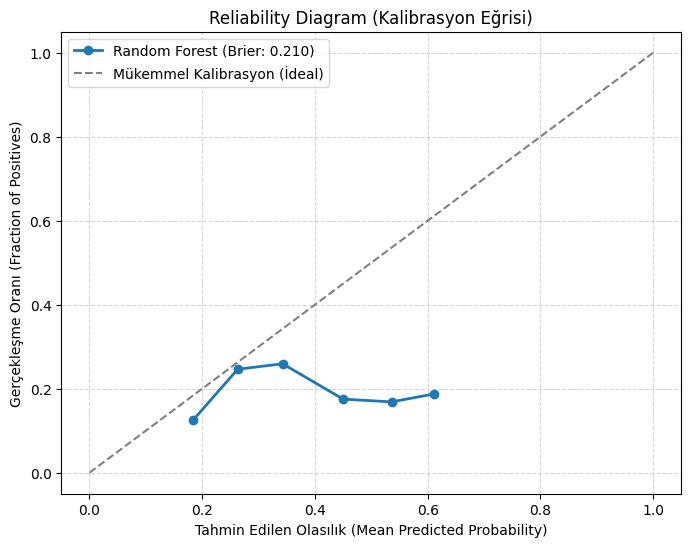

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# 1. VERİYİ YÜKLEME VE BÖLME (Sistemi ayağa kaldırma)
# Dosyayı Colab'a direkt yüklediğinizi varsayarak ana dizinden okuyoruz
df = pd.read_csv('/content/data/processed/features_advanced.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

X = df.drop(columns=['datetime', 'magnitude', 'target'])
y = df['target']
tarihler = df['datetime']

train_val_mask = (tarihler >= '2000-01-01') & (tarihler <= '2022-12-31')
test_mask = (tarihler >= '2023-01-01') & (tarihler <= '2024-12-31')

X_train_full, y_train_full = X[train_val_mask], y[train_val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Şampiyon Modeli tekrar eğitiyoruz
print("⏳ Model belleğe alınıyor...")
rf_final = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_train_full, y_train_full)
y_test_proba = rf_final.predict_proba(X_test)[:, 1]
print("✅ Sistem Hazır!\n")

# 2. KALİBRASYON VE BRIER SKORU (Taha'nın Görevi)
# Brier Skoru 0'a ne kadar yakınsa, modelin "olasılık" tahminleri o kadar güvenilirdir.
brier = brier_score_loss(y_test, y_test_proba)
print(f"Brier Skoru: {brier:.4f} (0'a yakın olması istenir)")

prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label=f'Random Forest (Brier: {brier:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Mükemmel Kalibrasyon (İdeal)')
plt.title('Reliability Diagram (Kalibrasyon Eğrisi)')
plt.xlabel('Tahmin Edilen Olasılık (Mean Predicted Probability)')
plt.ylabel('Gerçekleşme Oranı (Fraction of Positives)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
import folium
from folium.plugins import MarkerCluster

# Test seti için DataFrame'i tekrar oluşturalım
df_test = X_test.copy()
df_test['target'] = y_test
df_test['predicted'] = rf_final.predict(X_test)
df_test['datetime'] = df.loc[X_test.index, 'datetime'] # Tarihleri geri alıyoruz

# Sadece M >= 4.2 olan GERÇEK depremleri filtreleyelim ki modelin yakalayıp yakalayamadığını görelim
gercek_depremler = df_test[df_test['target'] == 1]

# Türkiye merkezli bir harita oluşturalım
m = folium.Map(location=[39.0, 35.0], zoom_start=6, tiles='CartoDB positron')

print(f"Haritaya işlenen M >= 4.2 gerçek deprem sayısı: {len(gercek_depremler)}")

for idx, row in gercek_depremler.iterrows():
    # Eğer model bildiyse (Doğru Pozitif) -> Yeşil
    if row['predicted'] == 1:
        renk = 'green'
        durum = 'Doğru Tahmin (True Positive)'
    # Eğer model bilemediyse (Yanlış Negatif) -> Kırmızı
    else:
        renk = 'red'
        durum = 'Kaçırılan Deprem (False Negative)'

    popup_text = f"Tarih: {row['datetime'].date()}<br>Durum: {durum}"

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color=renk,
        fill=True,
        fill_color=renk,
        fill_opacity=0.7,
        popup=popup_text
    ).add_to(m)

# Haritayı Colab'da görüntüle
m

Haritaya işlenen M >= 4.2 gerçek deprem sayısı: 517


In [ ]:
import joblib

# Proje planındaki teslimat dizinini oluşturalım (Opsiyonel, Colab ana dizinine de kaydedebiliriz)
import os
os.makedirs('models', exist_ok=True)

model_path = 'models/final_model.pkl'

# Şampiyon modeli kaydediyoruz
joblib.dump(rf_final, model_path)

print(f"🚀 TEBRİKLER! Projenin tüm kodlama süreci tamamlandı.")
print(f"Model başarıyla '{model_path}' konumuna kaydedildi.")
print("Lütfen sol taraftaki dosya yöneticisinden 'models' klasörünü açıp 'final_model.pkl' dosyasını bilgisayarınıza indirin.")

🚀 TEBRİKLER! Projenin tüm kodlama süreci tamamlandı.
Model başarıyla 'models/final_model.pkl' konumuna kaydedildi.
Lütfen sol taraftaki dosya yöneticisinden 'models' klasörünü açıp 'final_model.pkl' dosyasını bilgisayarınıza indirin.


In [ ]:
!pip install streamlit streamlit-folium
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.5/530.5 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 40.5 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 6s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦npm notice
npm notice New major version of npm available! 10.8.2 -> 11.14.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.14.1
npm notice To update run: npm install -g npm@11.14.1
npm notice
⠦

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import folium
from streamlit_folium import st_folium

# 1. Sayfa Ayarları
st.set_page_config(page_title="AI Deprem Erken Uyarı", page_icon="🌍", layout="wide")
st.title("🌍 Türkiye Deprem Risk Simülatörü (Random Forest)")
st.markdown("Bu arayüz, Kandilli sismik kataloğundan alınan anlık stres (b-value) ve komşuluk (KNN) verilerini kullanarak **M >= 4.2** büyüklüğündeki deprem riskini hesaplar.")

# 2. Veri ve Modeli Önbelleğe Alma (Hızlı çalışması için)
@st.cache_resource
def load_system():
    # Son güncel verimizi ve şampiyon modelimizi yüklüyoruz
    df = pd.read_csv('data/processed/features_advanced.csv')
    model = joblib.load('models/final_model.pkl')
    return df, model

try:
    df, model = load_system()
except FileNotFoundError:
    st.error("Hata: 'features_advanced.csv' veya 'final_model.pkl' dosyası bulunamadı. Lütfen yolları kontrol edin.")
    st.stop()

# 3. Sidebar (Yan Menü) Tasarımı
st.sidebar.header("⚙️ Simülasyon Ayarları")
st.sidebar.write("Test seti (2023-2024) üzerinden bir sismik olay seçerek modelin o anki kararını test edin:")

df['datetime'] = pd.to_datetime(df['datetime'])
df_test = df[df['datetime'] >= '2023-01-01'].copy()
df_test = df_test.sort_values('datetime', ascending=False) # En yeniler üstte

# Kullanıcıya tarih seçtirme
tarih_listesi = df_test['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S').tolist()
secilen_tarih = st.sidebar.selectbox("Tarih ve Saat Seçin:", tarih_listesi)

# Seçilen satırın tüm verilerini çekme
secilen_satir = df_test[df_test['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S') == secilen_tarih].iloc[0]

# 4. Model Tahmini (Prediction)
# Hedef değişkenleri çıkarıp sadece özellikleri modele veriyoruz
X_input = secilen_satir.drop(['datetime', 'magnitude', 'target']).values.reshape(1, -1)
risk_olasidigi = model.predict_proba(X_input)[0][1] * 100

# 5. Ana Ekran Bölünmesi (Metrikler ve Harita)
col1, col2 = st.columns([1, 2])

with col1:
    st.subheader("📊 Anlık Sismik Parametreler")
    st.write(f"📍 **Koordinat:** {secilen_satir['lat']:.2f}°N, {secilen_satir['lon']:.2f}°E")
    st.write(f"⬇️ **Derinlik:** {secilen_satir['depth_km']:.1f} km")
    st.write(f"📉 **Fay Stresi (b-value 90G):** {secilen_satir['b_value_90D']:.3f}")
    st.write(f"💥 **Son 7 Gündeki Deprem Sayısı:** {int(secilen_satir['count_events_7D'])}")

    st.markdown("---")
    st.subheader("🤖 Yapay Zeka Kararı")

    if risk_olasidigi > 50:
        st.error(f"⚠️ DİKKAT! YÜKSEK RİSK\n\nM >= 4.2 Deprem Olasılığı: **%{risk_olasidigi:.1f}**")
    elif risk_olasidigi > 25:
        st.warning(f"🟠 ORTA RİSK\n\nM >= 4.2 Deprem Olasılığı: **%{risk_olasidigi:.1f}**")
    else:
        st.success(f"✅ DÜŞÜK RİSK\n\nM >= 4.2 Deprem Olasılığı: **%{risk_olasidigi:.1f}**")

    st.info(f"Gerçekleşen Deprem Büyüklüğü: **M {secilen_satir['magnitude']:.1f}**")

with col2:
    st.subheader("🗺️ Risk Bölgesi Haritası")
    # Haritayı oluştur ve risk rengine göre işaretle
    renk = 'red' if risk_olasidigi > 50 else ('orange' if risk_olasidigi > 25 else 'green')
    m = folium.Map(location=[secilen_satir['lat'], secilen_satir['lon']], zoom_start=8, tiles='CartoDB positron')

    folium.Circle(
        location=[secilen_satir['lat'], secilen_satir['lon']],
        radius=15000, # 15 km çapında risk dairesi
        color=renk,
        fill=True,
        fill_color=renk,
        fill_opacity=0.4,
        popup=f"Risk: %{risk_olasidigi:.1f}"
    ).add_to(m)

    st_folium(m, width=800, height=450)

Overwriting app.py


In [ ]:
%%writefile app2.py
import streamlit as st
import pandas as pd
import joblib
import folium
from streamlit_folium import st_folium

# 1. Sayfa Ayarları (Emoji kaldırıldı, geniş ekran korundu)
st.set_page_config(page_title="Seismic Risk Simulator", layout="wide")

# 2. Özel CSS Enjeksiyonu (Lacivert Akademik Tema ve Şık Kutular)
st.markdown("""
<style>
    /* Arka plan rengi */
    .stApp { background-color: #f8fafc; }

    /* Akademik Ana Başlık Kutusu */
    .academic-title {
        background-color: #0f172a; /* Koyu Lacivert */
        color: #ffffff;
        padding: 25px 30px;
        border-radius: 8px;
        margin-bottom: 25px;
        border-left: 6px solid #3b82f6; /* Mavi Vurgu */
    }
    .academic-title h1 { color: #ffffff; margin: 0; font-size: 28px; font-family: 'Georgia', serif; }
    .academic-title h4 { color: #94a3b8; margin: 8px 0 0 0; font-size: 16px; font-weight: normal; font-family: 'Arial', sans-serif; }

    /* Alt Başlıklar */
    h2, h3 { color: #1e293b !important; font-family: 'Georgia', serif; border-bottom: 1px solid #cbd5e1; padding-bottom: 8px; font-size: 20px;}

    /* Veri Kutuları (Metric Boxes) */
    .metric-box {
        background-color: #ffffff;
        padding: 15px;
        border-radius: 5px;
        border-left: 4px solid #1e3a8a; /* Orta Lacivert */
        margin-bottom: 12px;
        box-shadow: 0 1px 3px rgba(0,0,0,0.1);
    }
    .metric-title { color: #64748b; font-size: 12px; text-transform: uppercase; font-weight: bold; margin-bottom: 5px; font-family: 'Arial', sans-serif;}
    .metric-value { color: #0f172a; font-size: 16px; font-weight: bold; font-family: 'Arial', sans-serif;}

    /* Risk Sonuç Kutuları */
    .risk-high { background-color: #fee2e2; border-left: 5px solid #ef4444; padding: 15px; border-radius: 5px; color: #7f1d1d; font-weight: bold; }
    .risk-medium { background-color: #fef3c7; border-left: 5px solid #f59e0b; padding: 15px; border-radius: 5px; color: #78350f; font-weight: bold; }
    .risk-low { background-color: #ecfdf5; border-left: 5px solid #10b981; padding: 15px; border-radius: 5px; color: #064e3b; font-weight: bold; }
</style>
""", unsafe_allow_html=True)

# 3. Akademik Başlık
st.markdown("""
<div class="academic-title">
    <h1>Türkiye Sismik Risk Simülatörü</h1>
    <h4>Introduction to Data Science Project | A Machine Learning Approach to Earthquake Forecasting</h4>
</div>
""", unsafe_allow_html=True)

# 4. Veri ve Modeli Önbelleğe Alma
@st.cache_resource
def load_system():
    df = pd.read_csv('data/processed/features_advanced.csv')
    model = joblib.load('models/final_model.pkl')
    return df, model

try:
    df, model = load_system()
except FileNotFoundError:
    st.error("Veri veya model dosyası bulunamadı. Lütfen dizinleri kontrol ediniz.")
    st.stop()

# 5. Sidebar (Yan Menü) Tasarımı
st.sidebar.markdown("<h3 style='color: #1e3a8a;'>Simülasyon Parametreleri</h3>", unsafe_allow_html=True)
st.sidebar.markdown("Test veri seti (2023-2024) üzerinden retrospektif analiz için sismik olay seçimi:")

df['datetime'] = pd.to_datetime(df['datetime'])
df_test = df[df['datetime'] >= '2023-01-01'].copy().sort_values('datetime', ascending=False)
tarih_listesi = df_test['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S').tolist()
secilen_tarih = st.sidebar.selectbox("Analiz Tarihi (UTC):", tarih_listesi)

secilen_satir = df_test[df_test['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S') == secilen_tarih].iloc[0]

# 6. Model Tahmini (Prediction)
X_input = secilen_satir.drop(['datetime', 'magnitude', 'target']).values.reshape(1, -1)
risk_olasidigi = model.predict_proba(X_input)[0][1] * 100

# 7. Ana Ekran Bölünmesi
col1, col2 = st.columns([1, 2])

with col1:
    st.markdown("### Sismolojik Değişkenler")

    # HTML/CSS tabanlı şık kutular (Emoji yerine modern kurumsal görünüm)
    st.markdown(f"""
    <div class="metric-box">
        <div class="metric-title">Koordinat (Enlem / Boylam)</div>
        <div class="metric-value">{secilen_satir['lat']:.2f}°N, {secilen_satir['lon']:.2f}°E</div>
    </div>
    <div class="metric-box">
        <div class="metric-title">Odak Derinliği</div>
        <div class="metric-value">{secilen_satir['depth_km']:.1f} km</div>
    </div>
    <div class="metric-box">
        <div class="metric-title">Stres İndeksi (b-value, 90 Gün)</div>
        <div class="metric-value">{secilen_satir['b_value_90D']:.3f}</div>
    </div>
    <div class="metric-box">
        <div class="metric-title">Bölgesel Aktivite (Son 7 Gün)</div>
        <div class="metric-value">{int(secilen_satir['count_events_7D'])} Sismik Olay</div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("### Sınıflandırma Çıktısı (Random Forest)")

    # Uyarı kutularını akademik formata çevirdik
    if risk_olasidigi > 50:
        st.markdown(f"<div class='risk-high'>RİSK SEVİYESİ: YÜKSEK<br>M ≥ 4.2 Olasılığı: %{risk_olasidigi:.1f}</div>", unsafe_allow_html=True)
        renk = '#ef4444'
    elif risk_olasidigi > 25:
        st.markdown(f"<div class='risk-medium'>RİSK SEVİYESİ: ORTA<br>M ≥ 4.2 Olasılığı: %{risk_olasidigi:.1f}</div>", unsafe_allow_html=True)
        renk = '#f59e0b'
    else:
        st.markdown(f"<div class='risk-low'>RİSK SEVİYESİ: DÜŞÜK<br>M ≥ 4.2 Olasılığı: %{risk_olasidigi:.1f}</div>", unsafe_allow_html=True)
        renk = '#10b981'

    st.markdown(f"<div style='margin-top: 15px; font-size: 13px; color: #64748b;'>* Ground Truth (Gerçekleşen Büyüklük): <b>M {secilen_satir['magnitude']:.1f}</b></div>", unsafe_allow_html=True)

with col2:
    st.markdown("### Mekânsal Risk Dağılımı")
    # Harita
    m = folium.Map(location=[secilen_satir['lat'], secilen_satir['lon']], zoom_start=8, tiles='CartoDB positron')

    folium.Circle(
        location=[secilen_satir['lat'], secilen_satir['lon']],
        radius=15000,
        color=renk,
        fill=True,
        fill_color=renk,
        fill_opacity=0.4,
        popup=f"Olasılık: %{risk_olasidigi:.1f}"
    ).add_to(m)

    st_folium(m, width=800, height=450)

Writing app2.py


In [ ]:
import urllib
print("Aşağıdaki IP Adresini Kopyalayın:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))

!streamlit run app2.py & npx localtunnel --port 8501

Aşağıdaki IP Adresini Kopyalayın: 130.211.119.180
⠙⠹⠸

your url is: https://long-vans-cross.loca.lt
2026-05-20 10:00:50.041 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://130.211.119.180:8501

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py

In [ ]:
import os
import zipfile

# Gerekli klasör mimarisini oluştur
os.makedirs('deprem_projesi/data/processed', exist_ok=True)
os.makedirs('deprem_projesi/models', exist_ok=True)

# Üretilen dosyaları ilgili klasörlere taşı/kopyala
if os.path.exists('features_advanced.csv'):
    os.rename('features_advanced.csv', 'deprem_projesi/data/processed/features_advanced.csv')
if os.path.exists('models/final_model.pkl'):
    os.rename('models/final_model.pkl', 'deprem_projesi/models/final_model.pkl')
if os.path.exists('app.py'):
    with open('app.py', 'r') as f: content = f.read()
    with open('deprem_projesi/app.py', 'w') as f: f.write(content)

# Bağımlılıklar dosyasını (requirements.txt) otomatik oluştur
requirements = """streamlit\nstreamlit-folium\npandas\nnumpy\nscikit-learn\nxgboost\nshap\njoblib\nfolium\n"""
with open('deprem_projesi/requirements.txt', 'w') as f:
    f.write(requirements)

# Tüm projeyi ZIP formatında paketle
def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                rel_path = os.path.relpath(os.path.join(root, file), os.path.dirname(folder_path))
                zipf.write(os.path.join(root, file), rel_path)

zip_folder('deprem_projesi', 'deprem_projesi_master_backup.zip')
print("🚀 Proje başarıyla klasörlendi ve paketlendi!")
print("Lütfen sol taraftaki dosya menüsünden 'deprem_projesi_master_backup.zip' dosyasını bilgisayarınıza indirin.")

🚀 Proje başarıyla klasörlendi ve paketlendi!
Lütfen sol taraftaki dosya menüsünden 'deprem_projesi_master_backup.zip' dosyasını bilgisayarınıza indirin.


In [ ]:
import os
import zipfile
import shutil

# 1. Gerekli klasör mimarisini temiz bir şekilde oluştur
os.makedirs('deprem_projesi_v2/data/processed', exist_ok=True)
os.makedirs('deprem_projesi_v2/models', exist_ok=True)

# 2. Dosyaları doğru yerlere KOPYALA (Taşıma yerine kopyalama daha güvenlidir)
if os.path.exists('features_advanced.csv'):
    shutil.copy('features_advanced.csv', 'deprem_projesi_v2/data/processed/features_advanced.csv')
elif os.path.exists('data/processed/features_advanced.csv'): # Eğer zaten oradaysa
    shutil.copy('data/processed/features_advanced.csv', 'deprem_projesi_v2/data/processed/features_advanced.csv')

if os.path.exists('models/final_model.pkl'):
    shutil.copy('models/final_model.pkl', 'deprem_projesi_v2/models/final_model.pkl')

if os.path.exists('app.py'):
    shutil.copy('app.py', 'deprem_projesi_v2/app.py')

# 3. Bağımlılıklar dosyasını (requirements.txt) otomatik oluştur
requirements = """streamlit\nstreamlit-folium\npandas\nnumpy\nscikit-learn\nxgboost\nshap\njoblib\nfolium\n"""
with open('deprem_projesi_v2/requirements.txt', 'w') as f:
    f.write(requirements)

# 4. Tüm projeyi ZIP formatında paketle
def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                rel_path = os.path.relpath(os.path.join(root, file), os.path.dirname(folder_path))
                zipf.write(os.path.join(root, file), rel_path)

zip_folder('deprem_projesi_v2', 'deprem_projesi_YENI_backup.zip')
print("🚀 Hata düzeltildi! Proje mükemmel hiyerarşiyle paketlendi.")
print("Lütfen sol taraftaki dosya menüsünden 'deprem_projesi_YENI_backup.zip' dosyasını indirin.")

🚀 Hata düzeltildi! Proje mükemmel hiyerarşiyle paketlendi.
Lütfen sol taraftaki dosya menüsünden 'deprem_projesi_YENI_backup.zip' dosyasını indirin.
